In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [10]:
def PlotPS_Timeseries(lat, lon, xlims, **kwargs):
    fig, ax = plt.subplots()

    for k, val in kwargs.items():
        ax.plot(val[0],
                val[1].PS.sel(lat=lat, lon=lon) - 100000,
                label=k,
                linestyle=val[2]
                )

    ax.set_ylabel("PS - 1000000 [Pa]")
    ax.set_xlabel("Time [minutes]")
    ax.set_title(f"Lat={lat}, lon={lon}")
    ax.set_xlim(xlims)
    ax.legend()

In [5]:
SCRATCH_NF = "/glade/derecho/scratch/nforcone"

# se_tstep_type = 1
TYPE_1_DIR = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_tstep_type_1/run"
TYPE_1_FILE = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_tstep_type_1.cam.h0i.0001-01-01-00000.nc"
TYPE_1_PATH = os.path.join(SCRATCH_NF, TYPE_1_DIR, TYPE_1_FILE)
type_1 = xr.open_dataset(TYPE_1_PATH).convert_calendar("standard")

# se_tstep_type = 2
TYPE_2_DIR = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_tstep_type_2/run"
TYPE_2_FILE = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_tstep_type_2.cam.h0i.0001-01-01-00000.nc"
TYPE_2_PATH = os.path.join(SCRATCH_NF, TYPE_2_DIR, TYPE_2_FILE)
type_2 = xr.open_dataset(TYPE_2_PATH).convert_calendar("standard")

# se_tstep_type = 4
TYPE_4_DIR = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb/run"
TYPE_4_FILE = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb.cam.h0i.0001-01-01-00000.nc"
TYPE_4_PATH = os.path.join(SCRATCH_NF, TYPE_4_DIR, TYPE_4_FILE)
type_4 = xr.open_dataset(TYPE_4_PATH).convert_calendar("standard")

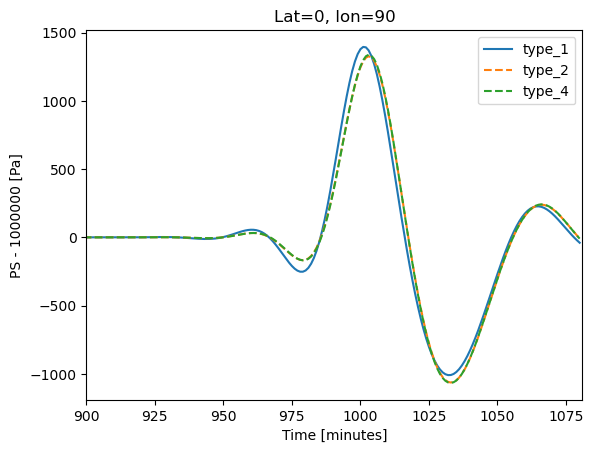

In [11]:
lat = 0
lon = 90
times = np.arange(0, 1081, 1)
xlims = (900, 1081)

PlotPS_Timeseries(lat,
                  lon,
                  xlims,
                  type_1=(times, type_1, 'solid'),
                  type_2=(times, type_2, 'dashed'),
                  type_4=(times, type_4, 'dashed')
                  )